In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
%matplotlib inline

In [331]:
np.random.seed(42)

In [178]:
from google.colab import files
trainCSV = files.upload()

df_train_absensi = pd.read_csv('train_absensi.csv')
df_train_mini_project = pd.read_csv('train_mini_project.csv')
df_train_pendaftaran = pd.read_csv('train_pendaftaran.csv')
df_train_pretest_ml = pd.read_csv('train_pretest_ml.csv')
df_train_pretest_py = pd.read_csv('train_pretest_py.csv')
df_train_pretest_st = pd.read_csv('train_pretest_st.csv')
df_train_weekly_quiz = pd.read_csv('train_weekly_quiz.csv')

Saving train_absensi.csv to train_absensi (1).csv
Saving train_mini_project.csv to train_mini_project (1).csv
Saving train_pendaftaran.csv to train_pendaftaran (1).csv
Saving train_pretest_ml.csv to train_pretest_ml (1).csv
Saving train_pretest_py.csv to train_pretest_py (1).csv
Saving train_pretest_st.csv to train_pretest_st (1).csv
Saving train_weekly_quiz.csv to train_weekly_quiz (1).csv


In [179]:
df_train_absensi.head()

,id,Timestamp,Tanggal hari ini,Pertemuan ke-,Kualitas materi,Siapa trainer pada hari ini ?,Bagaimana menurut Trainer pada hari ini ?,Kualitas trainer,Apakah ada saran secara keseluruhan ?,Kamu mengikuti Bootcamp Batch ?,Tanggal hari ini,Pertemuan ke
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,9/28/2023 21:20:43,9/28/2023,Intro,5,mf,Mantap,5,tidak ada,NaN,NaN,NaN
1,e475dfa1-7057-4718-8cec-82e17d598919,9/28/2023 21:28:13,9/28/2023,Pengenalan Bootcamp,5,mf,Trainer di malam ini sangat baik. Trainernya b...,5,-,NaN,NaN,NaN
2,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,10/3/2023 21:22:09,10/3/2023,Intro to data science,5,ars,Mantap,5,tidak ada,NaN,NaN,NaN
3,e475dfa1-7057-4718-8cec-82e17d598919,10/3/2023 21:23:41,10/3/2023,Introduction to Data Science,5,ars,Sangat baik. trainer bisa menjelaskan pengenal...,5,-,NaN,NaN,NaN
4,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,10/5/2023 21:28:38,10/5/2023,Installment,5,ars,Mantap,5,Tidak ada,NaN,NaN,NaN


In [180]:
df_train_absensi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11714 entries, 0 to 11713
Data columns (total 12 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   id                                         11714 non-null  object 
 1   Timestamp                                  11714 non-null  object 
 2   Tanggal hari ini                           249 non-null    object 
 3   Pertemuan ke-                              249 non-null    object 
 4   Kualitas materi                            11714 non-null  int64  
 5   Siapa trainer pada hari ini ?              11714 non-null  object 
 6   Bagaimana menurut Trainer pada hari ini ?  11714 non-null  object 
 7   Kualitas trainer                           11714 non-null  int64  
 8   Apakah ada saran secara keseluruhan ?      8207 non-null   object 
 9   Kamu mengikuti Bootcamp Batch ?            11688 non-null  float64
 10  Tanggal hari ini      

In [181]:
df_train_absensi.drop(['Timestamp', 'Tanggal hari ini', 'Pertemuan ke-', 'Bagaimana menurut Trainer pada hari ini ?', 'Apakah ada saran secara keseluruhan ?'], axis=1, inplace=True)

In [182]:
df_train_absensi.drop(['Tanggal hari ini '], axis=1, inplace=True)

In [183]:
df_train_absensi.drop(['Kamu mengikuti Bootcamp Batch ?', 'Pertemuan ke'], axis=1, inplace=True)

In [184]:
df_train_absensi['jumlah_kehadiran'] = df_train_absensi.groupby('id')['id'].transform('count')

In [185]:
df_train_absensi.isnull().sum()

,0
id,0
Kualitas materi,0
Siapa trainer pada hari ini ?,0
Kualitas trainer,0
jumlah_kehadiran,0


In [186]:
df_train_absensi.head()

,id,Kualitas materi,Siapa trainer pada hari ini ?,Kualitas trainer,jumlah_kehadiran
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,mf,5,9
1,e475dfa1-7057-4718-8cec-82e17d598919,5,mf,5,15
2,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,ars,5,9
3,e475dfa1-7057-4718-8cec-82e17d598919,5,ars,5,15
4,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,ars,5,9


In [187]:
df_train_absensi.head()
# selesai

,id,Kualitas materi,Siapa trainer pada hari ini ?,Kualitas trainer,jumlah_kehadiran
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,mf,5,9
1,e475dfa1-7057-4718-8cec-82e17d598919,5,mf,5,15
2,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,ars,5,9
3,e475dfa1-7057-4718-8cec-82e17d598919,5,ars,5,15
4,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,ars,5,9


In [188]:
df_train_pendaftaran.head()

,id,Timestamp,Pilihan Jadwal Kelas,Dari mana kamu mengetahui info ini ?,Status,Nama Kampus / Sekolah / Instansi,Alasan Mengikuti Bootcamp Data Science di Intelligo ID,Harapan setelah mengikuti Bootcamp,Unnamed: 0
0,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,1/12/2024 19:44:23,Bootcamp Data Science For Beginner Batch 8 - M...,Facebook,Mahasiswa,UGM,Ingin belajar data scientist,Bisa menjadi data scientist yg siap kerja,NaN
1,278d7fda-b155-48ea-a14a-c79813c8a257,3/3/2024 12:25:26,Bootcamp Data Science For Beginner Batch 8 - M...,Lain-lain,Mahasiswa,Universitas Mikroskil,Memperdalam Skill,Bisa menguasai skill bidang DS dan bisa memula...,NaN
2,5bc4a3cf-85c1-48f5-98b1-86cca6412ecb,4/17/2024 16:31:44,Bootcamp Data Science For Beginner Batch 9 - M...,Instagram,Fresh Graduates,unindra,ingin menambah ilmu,bekerja dibidangnya,NaN
3,8466868d-3b97-4c27-bd52-4a2e0aacecfe,4/19/2024 9:03:31,Bootcamp Data Science For Beginner Batch 9 - M...,Instagram,Umum,Universitas Pancasila,Ingin memperdalam ilmu dan mendapatkan pekerja...,Memilki ilmu yang lebih dari cukup untuk melak...,NaN
4,063c738e-30ae-49ad-877d-d97287e94231,4/21/2024 9:03:51,Bootcamp Data Science For Beginner Batch 9 - M...,Website,Pekerja aktif,Politeknik TEDC Bandung,Tertarik untuk switch career ke data analyst,Dapat memperoleh kompetensi yg sesuai dengan y...,NaN


In [189]:
df_train_pendaftaran.nunique()

,0
id,492
Timestamp,15
Pilihan Jadwal Kelas,2
Dari mana kamu mengetahui info ini ?,6
Status,4
Nama Kampus / Sekolah / Instansi,15
Alasan Mengikuti Bootcamp Data Science di Intelligo ID,15
Harapan setelah mengikuti Bootcamp,15
Unnamed: 0,480


In [190]:
df_train_pendaftaran.drop(['Timestamp', 'Dari mana kamu mengetahui info ini ?', 'Nama Kampus / Sekolah / Instansi', 'Alasan Mengikuti Bootcamp Data Science di Intelligo ID', 'Harapan setelah mengikuti Bootcamp', 'Unnamed: 0'], axis=1, inplace=True)

In [191]:
df_train_pendaftaran.isnull().sum()

,0
id,0
Pilihan Jadwal Kelas,130
Status,0


In [192]:
df_train_pendaftaran['Pilihan Jadwal Kelas'] = df_train_pendaftaran['Pilihan Jadwal Kelas'].fillna(
    df_train_pendaftaran['Pilihan Jadwal Kelas'].mode()[0]
)

In [193]:
df_train_mini_project.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 5 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   id                                                                              468 non-null    object 
 1   Timestamp                                                                       468 non-null    object 
 2   Bootcamp                                                                        116 non-null    object 
 3   Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view)  468 non-null    object 
 4   Unnamed: 0                                                                      462 non-null    float64
dtypes: float64(1), object(4)
memory usage: 18.4+ KB


In [194]:
df_train_pendaftaran.isnull().sum()

,0
id,0
Pilihan Jadwal Kelas,0
Status,0


In [195]:
df_train_pendaftaran.head()
# selesai

,id,Pilihan Jadwal Kelas,Status
0,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,Bootcamp Data Science For Beginner Batch 8 - M...,Mahasiswa
1,278d7fda-b155-48ea-a14a-c79813c8a257,Bootcamp Data Science For Beginner Batch 8 - M...,Mahasiswa
2,5bc4a3cf-85c1-48f5-98b1-86cca6412ecb,Bootcamp Data Science For Beginner Batch 9 - M...,Fresh Graduates
3,8466868d-3b97-4c27-bd52-4a2e0aacecfe,Bootcamp Data Science For Beginner Batch 9 - M...,Umum
4,063c738e-30ae-49ad-877d-d97287e94231,Bootcamp Data Science For Beginner Batch 9 - M...,Pekerja aktif


In [196]:
df_train_pretest_ml.head()

,id,Timestamp,Score,Apa yang dimaksud dengan vektorisasi dalam konteks jenis data?,Apa perbedaan utama antara Traditional Computing dan Machine Learning?,Manakah di antara berikut yang merupakan jenis Machine Learning?,Tahapan apa yang harus dilakukan setelah proses Data Preprocessing?,"Apa yang dimaksud dengan ""Confusion Matrix"" dalam konteks evaluasi model?",Metrics apa yang sesuai digunakan pada kasus data yang tidak seimbang (imbalanced data)?,Apa kegunaan Mean-Squared Error (MSE) dalam evaluasi model?,"Apa peran tahap ""Data Understanding"" dalam proses Machine Learning?","Pilihlah aspek-aspek yang termasuk dalam tahapan ""Data Preprocessing"" ?","Pilihlah algoritma Machine Learning yang termasuk dalam kategori ""Supervised Learning"" ?",Unnamed: 0
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,11/21/2023 19:49:17,50 / 100,b. Proses mengubah teks menjadi vektor bobot,b. Machine Learning dapat belajar dan meningka...,"a. Supervised Learning, b. Unsupervised Learni...",c. Data Understanding,b. Matriks untuk mengukur tingkat akurasi model,"b. Precision, Recall, atau F1-Score",a. Menghitung selisih antara nilai actual terh...,a. Menentukan algoritma Machine Learning yang ...,"Handling missing values, Removing duplicates, ...","Linear Regression, Decision Tree, Principal Co...",NaN
1,e475dfa1-7057-4718-8cec-82e17d598919,11/21/2023 19:51:03,70 / 100,b. Proses mengubah teks menjadi vektor bobot,b. Machine Learning dapat belajar dan meningka...,"a. Supervised Learning, b. Unsupervised Learni...",a. Model Training,d. Matriks untuk menilai model sudah 100%,"b. Precision, Recall, atau F1-Score",a. Menghitung selisih antara nilai actual terh...,c. Mengumpulkan dan memahami data yang akan di...,"Mengumpulkan data, Handling missing values, Re...","Linear Regression, Decision Tree",NaN
2,e475dfa1-7057-4718-8cec-82e17d598919,11/21/2023 21:13:29,100 / 100,b. Proses mengubah teks menjadi vektor bobot,b. Machine Learning dapat belajar dan meningka...,"a. Supervised Learning, b. Unsupervised Learning",a. Model Training,b. Matriks untuk mengukur tingkat akurasi model,"b. Precision, Recall, atau F1-Score",a. Menghitung selisih antara nilai actual terh...,c. Mengumpulkan dan memahami data yang akan di...,"Mengumpulkan data, Handling missing values, Re...","Linear Regression, Decision Tree",NaN
3,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,11/21/2023 21:13:30,100 / 100,b. Proses mengubah teks menjadi vektor bobot,b. Machine Learning dapat belajar dan meningka...,"a. Supervised Learning, b. Unsupervised Learning",a. Model Training,b. Matriks untuk mengukur tingkat akurasi model,"b. Precision, Recall, atau F1-Score",a. Menghitung selisih antara nilai actual terh...,c. Mengumpulkan dan memahami data yang akan di...,"Mengumpulkan data, Handling missing values, Re...","Linear Regression, Decision Tree",NaN
4,97774060-01f6-4a1f-8fba-bd5bb8825da8,5/2/2024 19:58:20,30 / 100,a. Proses membuat vektor dari data gambar,b. Machine Learning dapat belajar dan meningka...,"a. Supervised Learning, b. Unsupervised Learni...",c. Data Understanding,a. Matriks untuk membuat keputusan,c. Mean-Squared Error (MSE),b. Menghitung selisih antara nilai prediction ...,c. Mengumpulkan dan memahami data yang akan di...,"Mengumpulkan data, Handling missing values, Re...","Linear Regression, Decision Tree",NaN


In [197]:
df_train_pretest_ml.isnull().sum()

,0
id,0
Timestamp,0
Score,0
Apa yang dimaksud dengan vektorisasi dalam konteks jenis data?,0
Apa perbedaan utama antara Traditional Computing dan Machine Learning?,0
Manakah di antara berikut yang merupakan jenis Machine Learning?,0
Tahapan apa yang harus dilakukan setelah proses Data Preprocessing?,0
"Apa yang dimaksud dengan ""Confusion Matrix"" dalam konteks evaluasi model?",0
Metrics apa yang sesuai digunakan pada kasus data yang tidak seimbang (imbalanced data)?,0
Apa kegunaan Mean-Squared Error (MSE) dalam evaluasi model?,0


In [198]:
df_train_pretest_ml = df_train_pretest_ml[['id', 'Score']]

In [199]:
df_train_pretest_py.head()

,id,Timestamp,Score,1. Bahasa Python bisa digunakan untuk membuat apa saja ? kecuali...,"2. Salah satu syarat dalam mendefinisikan variabel, kecuali…",3. Jenis tipe data yang bersifat numerik adalah…,"4. Python bisa digunakan di online platform, dibawah ini platform mana yang benar ?","5. Python bisa digunakan di offline platform, dibawah ini platform mana yang benar ?",6. Workflow pada Data Science disebut...,"7. Dibawah ini mana yang benar, jika kita ingin membuat teks Selamat Datang",8. Tipe data untuk mencetak bilangan pecahan adalah...,"9. Penggunaan If-Else pada Python, biasanya digunakan untuk menentukan sebuah kondisi.\n\nBenar atau salah ?",10. Posisi if selalu berada setelah posisi else.\n\nBenar atau salah ?,Unnamed: 0
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,10/10/2023 19:46:09,80 / 100,AI,Tidak boleh ada angka dalam penamaan variabel,Integer,Google Colab,Jupyter Notebook,CRIPS-DM,Pilihan 1 dan 3 Benar,Float,Benar,Benar,NaN
1,74e5f3d2-cf26-41e7-8d59-84141179ddaa,1/15/2024 10:13:07,30 / 100,Game,Harus diawali dengan huruf abjad atau underscore,Dictionary,Semua Benar,Semua Benar,CRIPS-DM,"print(""Intelligo ID"")",Decimal,Benar,Salah,NaN
2,97774060-01f6-4a1f-8fba-bd5bb8825da8,1/15/2024 12:34:31,90 / 100,Semua Benar,Tidak boleh ada angka dalam penamaan variabel,Integer,Google Colab,Jupyter Notebook,Deployment,Pilihan 1 dan 3 Benar,Float,Benar,Salah,NaN
3,d0635b9d-75d2-410b-88f3-65c842f791ab,1/16/2024 16:59:19,60 / 100,AI,Tidak boleh ada angka dalam penamaan variabel,String,Google Colab,Jupyter Notebook,Business Understanding,Pilihan 1 dan 3 Benar,String,Benar,Salah,NaN
4,d0635b9d-75d2-410b-88f3-65c842f791ab,1/16/2024 17:21:09,80 / 100,AI,Tidak dapat diawali dengan angka,Integer,Google Colab,Jupyter Notebook,CRIPS-DM,Pilihan 1 dan 3 Benar,Float,Benar,Salah,NaN


In [200]:
df_train_pretest_py.isnull().sum()

,0
id,0
Timestamp,0
Score,0
1. Bahasa Python bisa digunakan untuk membuat apa saja ? kecuali...,0
"2. Salah satu syarat dalam mendefinisikan variabel, kecuali…",0
3. Jenis tipe data yang bersifat numerik adalah…,0
"4. Python bisa digunakan di online platform, dibawah ini platform mana yang benar ?",0
"5. Python bisa digunakan di offline platform, dibawah ini platform mana yang benar ?",0
6. Workflow pada Data Science disebut...,0
"7. Dibawah ini mana yang benar, jika kita ingin membuat teks Selamat Datang",0


In [201]:
df_train_pretest_py = df_train_pretest_py[['id', 'Score']]

In [202]:
df_train_pretest_st.head()

,id,Timestamp,Score,Yang merupakan ukuran pemusatan data adalah :,Median adalah:,Rata-rata (mean) dihitung dengan cara :,"Jika sebuah data memiliki outlier, ukuran pemusatan data yang paling terpengaruh adalah:",Modus adalah:,Deviasi adalah:,Varians dihitung dengan cara:,"Jika deviasi standar suatu dataset adalah nol, maka:",Deviasi standar yang lebih tinggi menunjukkan:,Korelasi statistik mengukur:,Koefisien korelasi Pearson digunakan untuk mengukur korelasi antara dua variabel yang bersifat:,"Jika koefisien korelasi antara dua variabel adalah -0,75, maka hubungan antara kedua variabel tersebut adalah:",Pernyataan yang diajukan untuk diuji secara statistik disebut:,Pernyataan alternatif dalam pengujian hipotesis yang menyatakan adanya perbedaan atau hubungan adalah:,"Dalam pengujian hipotesis, jika kita menyatakan ""Gagal ditolak,"" apa yang ingin kita tunjukkan?",Unnamed: 0
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,11/30/2023 20:08:17,75 / 100,d) Median,b) Nilai tengah saat data diurutkan dari terke...,b) Menjumlahkan semua nilai dalam data dan mem...,a) Rata-rata (mean),a) Nilai yang paling sering muncul dalam data.,b) Ukuran penyebaran data,c) Mengkuadratkan selisih setiap nilai dalam d...,b) Dataset memiliki nilai yang sama,c) Data yang lebih simetris,b) Hubungan linier antara dua variabel,b) Kuantitatif diskrit,c) Hubungan negatif kuat,c) Hipotesis statistik,b) Hipotesis alternatif,a. Kita menerima hipotesis nol (Ho).,NaN
1,d0635b9d-75d2-410b-88f3-65c842f791ab,2/29/2024 15:20:25,70 / 100,d) Median,b) Nilai tengah saat data diurutkan dari terke...,b) Menjumlahkan semua nilai dalam data dan mem...,a) Rata-rata (mean),a) Nilai yang paling sering muncul dalam data.,b) Ukuran penyebaran data,c) Mengkuadratkan selisih setiap nilai dalam d...,b) Dataset memiliki nilai yang sama,b) Data yang lebih tersebar,b) Hubungan linier antara dua variabel,a) Kategorikal,c) Hubungan negatif kuat,c) Hipotesis statistik,c) Statistik uji,a. Kita menerima hipotesis nol (Ho).,NaN
2,d0635b9d-75d2-410b-88f3-65c842f791ab,2/29/2024 15:26:46,100 / 100,d) Median,b) Nilai tengah saat data diurutkan dari terke...,b) Menjumlahkan semua nilai dalam data dan mem...,a) Rata-rata (mean),a) Nilai yang paling sering muncul dalam data.,b) Ukuran penyebaran data,c) Mengkuadratkan selisih setiap nilai dalam d...,b) Dataset memiliki nilai yang sama,b) Data yang lebih tersebar,b) Hubungan linier antara dua variabel,c) Kuantitatif kontinu,c) Hubungan negatif kuat,c) Hipotesis statistik,b) Hipotesis alternatif,d. Kita tidak memiliki cukup bukti untuk menol...,NaN
3,97774060-01f6-4a1f-8fba-bd5bb8825da8,2/29/2024 19:48:48,100 / 100,d) Median,b) Nilai tengah saat data diurutkan dari terke...,b) Menjumlahkan semua nilai dalam data dan mem...,a) Rata-rata (mean),a) Nilai yang paling sering muncul dalam data.,b) Ukuran penyebaran data,c) Mengkuadratkan selisih setiap nilai dalam d...,b) Dataset memiliki nilai yang sama,b) Data yang lebih tersebar,b) Hubungan linier antara dua variabel,c) Kuantitatif kontinu,c) Hubungan negatif kuat,c) Hipotesis statistik,b) Hipotesis alternatif,d. Kita tidak memiliki cukup bukti untuk menol...,NaN
4,74e5f3d2-cf26-41e7-8d59-84141179ddaa,2/29/2024 19:59:57,65 / 100,a) Jangkauan (range),b) Nilai tengah saat data diurutkan dari terke...,b) Menjumlahkan semua nilai dalam data dan mem...,c) Modus (mode),a) Nilai yang paling sering muncul dalam data.,d) Ukuran hubungan linear antara dua variabel,c) Mengkuadratkan selisih setiap nilai dalam d...,c) Dataset memiliki variasi yang besar,b) Data yang lebih tersebar,c) Distribusi data dalam satu variabel,b) Kuantitatif diskrit,c) Hubungan negatif kuat,c) Hipotesis statistik,b) Hipotesis alternatif,d. Kita tidak memiliki cukup bukti untuk menol...,NaN


In [203]:
df_train_pretest_st = df_train_pretest_st[['id', 'Score']]

In [204]:
def convert_score_to_float(df, score_col):
    df[score_col] = df[score_col].str.split(' / ').str[0].astype(float) / df[score_col].str.split(' / ').str[1].astype(float)
    return df

df_train_pretest_ml = convert_score_to_float(df_train_pretest_ml, 'Score')
df_train_pretest_py = convert_score_to_float(df_train_pretest_py, 'Score')
df_train_pretest_st = convert_score_to_float(df_train_pretest_st, 'Score')

In [205]:
display(df_train_pretest_ml.head())
# selesai
# df_train_pretest_ml.to_csv('df_train_pretest_ml.csv', index=False)

,id,Score
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,0.5
1,e475dfa1-7057-4718-8cec-82e17d598919,0.7
2,e475dfa1-7057-4718-8cec-82e17d598919,1.0
3,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,1.0
4,97774060-01f6-4a1f-8fba-bd5bb8825da8,0.3


In [206]:
display(df_train_pretest_py.head())
# selesai

,id,Score
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,0.8
1,74e5f3d2-cf26-41e7-8d59-84141179ddaa,0.3
2,97774060-01f6-4a1f-8fba-bd5bb8825da8,0.9
3,d0635b9d-75d2-410b-88f3-65c842f791ab,0.6
4,d0635b9d-75d2-410b-88f3-65c842f791ab,0.8


In [207]:
display(df_train_pretest_st.head())
# selesai

,id,Score
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,0.75
1,d0635b9d-75d2-410b-88f3-65c842f791ab,0.70
2,d0635b9d-75d2-410b-88f3-65c842f791ab,1.00
3,97774060-01f6-4a1f-8fba-bd5bb8825da8,1.00
4,74e5f3d2-cf26-41e7-8d59-84141179ddaa,0.65


In [208]:
df_train_weekly_quiz.head()

,id,Timestamp,Batch,Share link Google Colab kamu disini (jangan lupa diberi akses view),Unnamed: 0
0,6a274d5b-677d-4929-aea5-ee7e74b22148,5/19/2025 13:37:10,10,https://colab.research.google.com/xxxxxxxxxxxx...,NaN
1,ab63b367-3fca-4928-a09d-7193405c35e6,5/21/2025 4:43:23,10,https://colab.research.google.com/xxxxxxxxxxxx...,NaN
2,c9a82866-52ad-4597-8b87-453b4bc3a9d7,5/22/2025 21:49:12,10,https://colab.research.google.com/xxxxxxxxxxxx...,NaN
3,ab63b367-3fca-4928-a09d-7193405c35e6,5/22/2025 22:12:58,10,https://colab.research.google.com/xxxxxxxxxxxx...,NaN
4,6a274d5b-677d-4929-aea5-ee7e74b22148,5/26/2025 19:19:15,12,https://colab.research.google.com/xxxxxxxxxxxx...,NaN


In [209]:
df_train_weekly_quiz = df_train_weekly_quiz[['id']]
display(df_train_weekly_quiz.head())

,id
0,6a274d5b-677d-4929-aea5-ee7e74b22148
1,ab63b367-3fca-4928-a09d-7193405c35e6
2,c9a82866-52ad-4597-8b87-453b4bc3a9d7
3,ab63b367-3fca-4928-a09d-7193405c35e6
4,6a274d5b-677d-4929-aea5-ee7e74b22148


In [210]:
df_train_weekly_quiz['jumlah_quiz_dikerjakan'] = df_train_weekly_quiz.groupby('id')['id'].transform('count')

In [211]:
display(df_train_weekly_quiz.head())
# selesai

,id,jumlah_quiz_dikerjakan
0,6a274d5b-677d-4929-aea5-ee7e74b22148,2
1,ab63b367-3fca-4928-a09d-7193405c35e6,3
2,c9a82866-52ad-4597-8b87-453b4bc3a9d7,2
3,ab63b367-3fca-4928-a09d-7193405c35e6,3
4,6a274d5b-677d-4929-aea5-ee7e74b22148,2


In [212]:
df_train_mini_project.head()

,id,Timestamp,Bootcamp,Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view),Unnamed: 0
0,84e82477-5fb8-432b-9c0f-6bd0306ca028,8/4/2024 17:07:07,NaN,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN
1,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,8/9/2024 11:14:41,NaN,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN
2,c9e8e549-6753-4996-9924-8000e409dca2,5/31/2025 11:17:39,Offline,https://www.canva.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN
3,141ebfff-2112-4fb0-9522-2f6a34f388a7,6/1/2025 8:31:16,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN
4,c9a82866-52ad-4597-8b87-453b4bc3a9d7,6/8/2025 15:30:27,Online,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN


In [213]:
df_train_mini_project['Bootcamp'] = df_train_mini_project['Bootcamp'].fillna(
    df_train_mini_project['Bootcamp'].mode()[0]
)

In [214]:
df_train_mini_project['jumlah_mini_project_dikerjakan'] = df_train_mini_project.groupby('id')['id'].transform('count')
display(df_train_mini_project.head())

,id,Timestamp,Bootcamp,Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view),Unnamed: 0,jumlah_mini_project_dikerjakan
0,84e82477-5fb8-432b-9c0f-6bd0306ca028,8/4/2024 17:07:07,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
1,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,8/9/2024 11:14:41,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
2,c9e8e549-6753-4996-9924-8000e409dca2,5/31/2025 11:17:39,Offline,https://www.canva.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
3,141ebfff-2112-4fb0-9522-2f6a34f388a7,6/1/2025 8:31:16,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
4,c9a82866-52ad-4597-8b87-453b4bc3a9d7,6/8/2025 15:30:27,Online,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1


In [215]:
df_train_mini_project.head()
# selesai

,id,Timestamp,Bootcamp,Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view),Unnamed: 0,jumlah_mini_project_dikerjakan
0,84e82477-5fb8-432b-9c0f-6bd0306ca028,8/4/2024 17:07:07,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
1,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,8/9/2024 11:14:41,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
2,c9e8e549-6753-4996-9924-8000e409dca2,5/31/2025 11:17:39,Offline,https://www.canva.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
3,141ebfff-2112-4fb0-9522-2f6a34f388a7,6/1/2025 8:31:16,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
4,c9a82866-52ad-4597-8b87-453b4bc3a9d7,6/8/2025 15:30:27,Online,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1


In [216]:
df_train_mini_project.head()

,id,Timestamp,Bootcamp,Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view),Unnamed: 0,jumlah_mini_project_dikerjakan
0,84e82477-5fb8-432b-9c0f-6bd0306ca028,8/4/2024 17:07:07,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
1,d8e7fd49-fb6b-4a43-9ca1-b4d4c80a3ee3,8/9/2024 11:14:41,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
2,c9e8e549-6753-4996-9924-8000e409dca2,5/31/2025 11:17:39,Offline,https://www.canva.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
3,141ebfff-2112-4fb0-9522-2f6a34f388a7,6/1/2025 8:31:16,Offline,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1
4,c9a82866-52ad-4597-8b87-453b4bc3a9d7,6/8/2025 15:30:27,Online,https://docs.google.com/xxxxxxxxxxxxxxxxxxxxxxxxx,NaN,1


In [217]:
df_train = df_train_absensi \
    .merge(df_train_pendaftaran, on='id', how='left') \
    .merge(df_train_pretest_ml, on='id', how='left') \
    .merge(df_train_pretest_py, on='id', how='left') \
    .merge(df_train_pretest_st, on='id', how='left') \
    .merge(df_train_mini_project, on='id', how='left') \
    .merge(df_train_weekly_quiz, on='id', how='left')

In [218]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12150 entries, 0 to 12149
Data columns (total 16 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   id                                                                              12150 non-null  object 
 1   Kualitas materi                                                                 12150 non-null  int64  
 2   Siapa trainer pada hari ini ?                                                   12150 non-null  object 
 3   Kualitas trainer                                                                12150 non-null  int64  
 4   jumlah_kehadiran                                                                12150 non-null  int64  
 5   Pilihan Jadwal Kelas                                                            11544 non-null  object 
 6   Status        

In [219]:
df_train.drop(['Timestamp', 'Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view)', 'Unnamed: 0'], axis=1, inplace=True)

In [220]:
df_train.head()

,id,Kualitas materi,Siapa trainer pada hari ini ?,Kualitas trainer,jumlah_kehadiran,Pilihan Jadwal Kelas,Status,Score_x,Score_y,Score,Bootcamp,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan
0,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,mf,5,9,NaN,NaN,0.5,0.8,0.75,NaN,NaN,NaN
1,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,mf,5,9,NaN,NaN,1.0,0.8,0.75,NaN,NaN,NaN
2,e475dfa1-7057-4718-8cec-82e17d598919,5,mf,5,15,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN
3,e475dfa1-7057-4718-8cec-82e17d598919,5,mf,5,15,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,b65d1017-228d-483a-b0eb-3ac26cc9e9bd,5,ars,5,9,NaN,NaN,0.5,0.8,0.75,NaN,NaN,NaN


In [221]:
df_train_absensi['id'].nunique()

509

In [222]:
df_train['id'].nunique()

509

<Axes: >

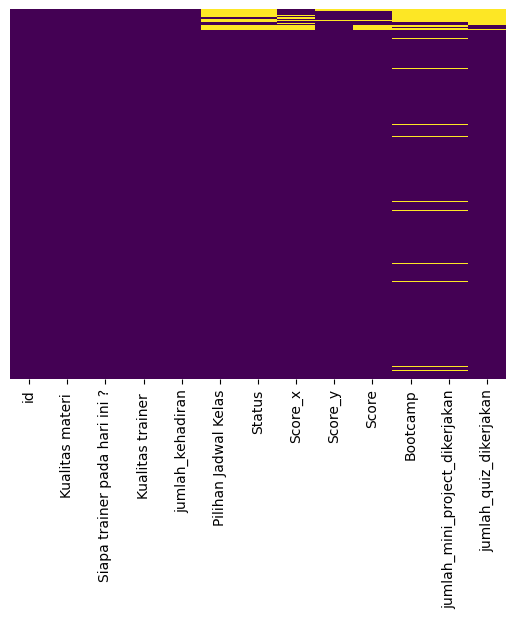

In [223]:
sns.heatmap(df_train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [224]:
df_train['Bootcamp'].isnull().sum()

np.int64(978)

In [225]:
df_train['Bootcamp'] = df_train.groupby('id')['Bootcamp'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

/tmp/ipython-input-582743888.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)


In [226]:
# IMPUTE

In [227]:
df_train.isnull().sum()

,0
id,0
Kualitas materi,0
Siapa trainer pada hari ini ?,0
Kualitas trainer,0
jumlah_kehadiran,0
Pilihan Jadwal Kelas,606
Status,606
Score_x,311
Score_y,61
Score,283


In [228]:
df_train.isnull().sum()

,0
id,0
Kualitas materi,0
Siapa trainer pada hari ini ?,0
Kualitas trainer,0
jumlah_kehadiran,0
Pilihan Jadwal Kelas,606
Status,606
Score_x,311
Score_y,61
Score,283


In [229]:
global_mode = df_train['Bootcamp'].mode()[0]
df_train['Bootcamp'] = df_train['Bootcamp'].fillna(global_mode)

In [230]:
df_train['Bootcamp'].isnull().sum()

np.int64(0)

In [231]:
global_mode = df_train['Pilihan Jadwal Kelas'].mode()[0]
df_train['Pilihan Jadwal Kelas'] = df_train['Pilihan Jadwal Kelas'].fillna(global_mode)

In [232]:
global_mode = df_train['Status'].mode()[0]
df_train['Status'] = df_train['Status'].fillna(global_mode)

In [233]:
kolom_nilai = ['Score_x', 'Score_y', 'Score', 'jumlah_mini_project_dikerjakan', 'jumlah_quiz_dikerjakan']

df_train[kolom_nilai] = df_train.groupby('id')[kolom_nilai].transform(
    lambda x: x.fillna(x.mean())
)

In [234]:
df_train[kolom_nilai] = df_train.groupby('id')[kolom_nilai].transform(
    lambda x: x.fillna(0)
)

In [235]:
agg_funcs = {
    'Kualitas materi ': 'mean',
    'Kualitas trainer ': 'mean',
    'jumlah_kehadiran': 'mean',
    'Score_x': 'mean',
    'Score_y': 'mean',
    'Score': 'mean',
    'jumlah_mini_project_dikerjakan': 'mean',
    'jumlah_quiz_dikerjakan': 'mean',
    'Siapa trainer pada hari ini ?': lambda x: x.mode()[0] if not x.mode().empty else None,
    'Pilihan Jadwal Kelas': lambda x: x.mode()[0] if not x.mode().empty else None,
    'Status': lambda x: x.mode()[0] if not x.mode().empty else None,
    'Bootcamp': lambda x: x.mode()[0] if not x.mode().empty else None
}

df_train_final = df_train.groupby('id').agg(agg_funcs)

In [236]:
df_train_final = df_train_final.reset_index()

In [237]:
df_train_final.head()

,id,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,Siapa trainer pada hari ini ?,Pilihan Jadwal Kelas,Status,Bootcamp
0,0a986dd7-a658-40a9-9d1b-d3074e036e35,4.566667,4.333333,30.0,1.0,0.9,1.0,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 8 - M...,Fresh Graduates,Offline
1,0aa927af-2e14-47b5-bb75-c1c700b13262,4.440000,4.480000,25.0,0.5,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Fresh Graduates,Offline
2,0abe9114-4d57-4368-9b74-8ff8d5ab22cf,4.388889,4.722222,18.0,0.5,0.9,0.9,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 8 - M...,Mahasiswa,Offline
3,0b187bd8-2c9e-4c1a-ad95-1ac60fa3f39d,4.400000,4.550000,20.0,0.4,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Pekerja aktif,Offline
4,0b5bc2f8-6b6b-4cd8-abdd-7c9350676492,4.346154,4.384615,26.0,0.4,0.8,0.7,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 9 - M...,Umum,Offline


In [238]:
df_train_final['rata_rata_score'] = df_train_final[['Score_x', 'Score_y', 'Score']].mean(axis=1)

In [239]:
df_train_final['id'].nunique()

509

In [240]:
df_train_final.head()

,id,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,Siapa trainer pada hari ini ?,Pilihan Jadwal Kelas,Status,Bootcamp,rata_rata_score
0,0a986dd7-a658-40a9-9d1b-d3074e036e35,4.566667,4.333333,30.0,1.0,0.9,1.0,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 8 - M...,Fresh Graduates,Offline,0.966667
1,0aa927af-2e14-47b5-bb75-c1c700b13262,4.440000,4.480000,25.0,0.5,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Fresh Graduates,Offline,0.733333
2,0abe9114-4d57-4368-9b74-8ff8d5ab22cf,4.388889,4.722222,18.0,0.5,0.9,0.9,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 8 - M...,Mahasiswa,Offline,0.766667
3,0b187bd8-2c9e-4c1a-ad95-1ac60fa3f39d,4.400000,4.550000,20.0,0.4,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Pekerja aktif,Offline,0.700000
4,0b5bc2f8-6b6b-4cd8-abdd-7c9350676492,4.346154,4.384615,26.0,0.4,0.8,0.7,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 9 - M...,Umum,Offline,0.633333


In [241]:
X = df_train_final.drop(columns=['id'])

In [242]:
X.head()

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,Siapa trainer pada hari ini ?,Pilihan Jadwal Kelas,Status,Bootcamp,rata_rata_score
0,4.566667,4.333333,30.0,1.0,0.9,1.0,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 8 - M...,Fresh Graduates,Offline,0.966667
1,4.440000,4.480000,25.0,0.5,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Fresh Graduates,Offline,0.733333
2,4.388889,4.722222,18.0,0.5,0.9,0.9,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 8 - M...,Mahasiswa,Offline,0.766667
3,4.400000,4.550000,20.0,0.4,0.8,0.9,0.0,1.0,mdn,Bootcamp Data Science For Beginner Batch 9 - M...,Pekerja aktif,Offline,0.700000
4,4.346154,4.384615,26.0,0.4,0.8,0.7,0.0,1.0,ars,Bootcamp Data Science For Beginner Batch 9 - M...,Umum,Offline,0.633333


In [243]:
X = pd.get_dummies(X, columns=['Status'], drop_first=False)

In [244]:
X = pd.get_dummies(X, columns=['Siapa trainer pada hari ini ?', 'Pilihan Jadwal Kelas', 'Bootcamp'], drop_first=True)

In [245]:
X.head()

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,4.566667,4.333333,30.0,1.0,0.9,1.0,0.0,1.0,0.966667,True,False,False,False,False,True,False,False,False,False
1,4.440000,4.480000,25.0,0.5,0.8,0.9,0.0,1.0,0.733333,True,False,False,False,False,True,False,False,True,False
2,4.388889,4.722222,18.0,0.5,0.9,0.9,0.0,1.0,0.766667,False,True,False,False,False,False,False,False,False,False
3,4.400000,4.550000,20.0,0.4,0.8,0.9,0.0,1.0,0.700000,False,False,True,False,False,True,False,False,True,False
4,4.346154,4.384615,26.0,0.4,0.8,0.7,0.0,1.0,0.633333,False,False,False,True,False,False,False,False,True,False


In [246]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("First 5 rows of the scaled DataFrame X:")
display(X_scaled.head())

First 5 rows of the scaled DataFrame X:


,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,0.653333,0.466667,1.000000,1.0,0.9,1.0,0.0,0.333333,0.966667,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.552000,0.584000,0.827586,0.5,0.8,0.9,0.0,0.333333,0.733333,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.511111,0.777778,0.586207,0.5,0.9,0.9,0.0,0.333333,0.766667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.520000,0.640000,0.655172,0.4,0.8,0.9,0.0,0.333333,0.700000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.476923,0.507692,0.862069,0.4,0.8,0.7,0.0,0.333333,0.633333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [247]:
from google.colab import files
uploaded_files = files.upload()

df_test_absensi = pd.read_csv('test_absensi.csv')
df_test_mini_project = pd.read_csv('test_mini_project.csv')
df_test_pendaftaran = pd.read_csv('test_pendaftaran.csv')
df_test_pretest_ml = pd.read_csv('test_pretest_ml.csv')
df_test_pretest_py = pd.read_csv('test_pretest_py.csv')
df_test_pretest_st = pd.read_csv('test_pretest_st.csv')
df_test_weekly_quiz = pd.read_csv('test_weekly_quiz.csv')

Saving test_absensi.csv to test_absensi (1).csv
Saving test_mini_project.csv to test_mini_project (1).csv
Saving test_pendaftaran.csv to test_pendaftaran (1).csv
Saving test_pretest_ml.csv to test_pretest_ml (1).csv
Saving test_pretest_py.csv to test_pretest_py (1).csv
Saving test_pretest_st.csv to test_pretest_st (1).csv
Saving test_weekly_quiz.csv to test_weekly_quiz (1).csv


In [248]:
df_test_absensi.drop(['Timestamp', 'Tanggal hari ini', 'Pertemuan ke-', 'Bagaimana menurut Trainer pada hari ini ?', 'Apakah ada saran secara keseluruhan ?'], axis=1, inplace=True)

In [249]:
df_test_absensi.drop(['Tanggal hari ini '], axis=1, inplace=True)

In [250]:
df_test_absensi.drop(['Kamu mengikuti Bootcamp Batch ?', 'Pertemuan ke'], axis=1, inplace=True)

In [251]:
df_test_absensi['jumlah_kehadiran'] = df_test_absensi.groupby('id')['id'].transform('count')

In [252]:
df_test_pendaftaran.drop(['Timestamp', 'Dari mana kamu mengetahui info ini ?', 'Nama Kampus / Sekolah / Instansi', 'Alasan Mengikuti Bootcamp Data Science di Intelligo ID', 'Harapan setelah mengikuti Bootcamp', 'Unnamed: 0'], axis=1, inplace=True)

In [253]:
df_test_pendaftaran['Pilihan Jadwal Kelas'] = df_test_pendaftaran['Pilihan Jadwal Kelas'].fillna(
    df_test_pendaftaran['Pilihan Jadwal Kelas'].mode()[0]
)

In [254]:
df_test_pretest_ml = df_test_pretest_ml[['id', 'Score']]

In [255]:
df_test_pretest_py = df_test_pretest_py[['id', 'Score']]

In [256]:
df_test_pretest_st = df_test_pretest_st[['id', 'Score']]

In [257]:
def convert_score_to_float(df, score_col):
    df[score_col] = df[score_col].str.split(' / ').str[0].astype(float) / df[score_col].str.split(' / ').str[1].astype(float)
    return df

df_test_pretest_ml = convert_score_to_float(df_test_pretest_ml, 'Score')
df_test_pretest_py = convert_score_to_float(df_test_pretest_py, 'Score')
df_test_pretest_st = convert_score_to_float(df_test_pretest_st, 'Score')

In [258]:
df_test_weekly_quiz = df_test_weekly_quiz[['id']]

In [259]:
df_test_weekly_quiz['jumlah_quiz_dikerjakan'] = df_test_weekly_quiz.groupby('id')['id'].transform('count')

In [260]:
df_test_mini_project['Bootcamp'] = df_test_mini_project['Bootcamp'].fillna(
    df_test_mini_project['Bootcamp'].mode()[0]
)

In [261]:
df_test_mini_project['jumlah_mini_project_dikerjakan'] = df_test_mini_project.groupby('id')['id'].transform('count')

In [262]:
df_test = df_test_absensi \
    .merge(df_test_pendaftaran, on='id', how='left') \
    .merge(df_test_pretest_ml, on='id', how='left') \
    .merge(df_test_pretest_py, on='id', how='left') \
    .merge(df_test_pretest_st, on='id', how='left') \
    .merge(df_test_mini_project, on='id', how='left') \
    .merge(df_test_weekly_quiz, on='id', how='left')

In [263]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1113 entries, 0 to 1112
Data columns (total 16 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   id                                                                              1113 non-null   object 
 1   Kualitas materi                                                                 1113 non-null   int64  
 2   Siapa trainer pada hari ini ?                                                   1113 non-null   object 
 3   Kualitas trainer                                                                1113 non-null   int64  
 4   jumlah_kehadiran                                                                1113 non-null   int64  
 5   Pilihan Jadwal Kelas                                                            490 non-null    object 
 6   Status          

In [264]:
df_test.drop(['Timestamp', 'Share link Google Slide atau Canva kamu disini (jangan lupa diberi akses view)', 'Unnamed: 0'], axis=1, inplace=True)

In [265]:
df_test_absensi['id'].nunique()

48

In [266]:
df_test['id'].nunique()

48

In [267]:
# IMPUTE

In [268]:
df_test['Bootcamp'] = df_test.groupby('id')['Bootcamp'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
)

/tmp/ipython-input-3777563481.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)


In [269]:
global_mode = df_test['Bootcamp'].mode()[0]
df_test['Bootcamp'] = df_test['Bootcamp'].fillna(global_mode)

In [270]:
global_mode = df_test['Pilihan Jadwal Kelas'].mode()[0]
df_test['Pilihan Jadwal Kelas'] = df_test['Pilihan Jadwal Kelas'].fillna(global_mode)

In [271]:
global_mode = df_test['Status'].mode()[0]
df_test['Status'] = df_test['Status'].fillna(global_mode)

In [272]:
kolom_nilai = ['Score_x', 'Score_y', 'Score', 'jumlah_mini_project_dikerjakan', 'jumlah_quiz_dikerjakan']

df_test[kolom_nilai] = df_test.groupby('id')[kolom_nilai].transform(
    lambda x: x.fillna(x.mean())
)

In [273]:
df_test[kolom_nilai] = df_test.groupby('id')[kolom_nilai].transform(
    lambda x: x.fillna(0)
)

In [274]:
df_test_final = df_test.groupby('id').agg(agg_funcs)

In [275]:
# ini belum
df_test_final = df_test_final.reset_index()

In [276]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48 non-null     object 
 1   Kualitas materi                 48 non-null     float64
 2   Kualitas trainer                48 non-null     float64
 3   jumlah_kehadiran                48 non-null     float64
 4   Score_x                         48 non-null     float64
 5   Score_y                         48 non-null     float64
 6   Score                           48 non-null     float64
 7   jumlah_mini_project_dikerjakan  48 non-null     float64
 8   jumlah_quiz_dikerjakan          48 non-null     float64
 9   Siapa trainer pada hari ini ?   48 non-null     object 
 10  Pilihan Jadwal Kelas            48 non-null     object 
 11  Status                          48 non-null     object 
 12  Bootcamp                        48 non

In [277]:
df_test_final['rata_rata_score'] = df_test_final[['Score_x', 'Score_y', 'Score']].mean(axis=1)

In [278]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48 non-null     object 
 1   Kualitas materi                 48 non-null     float64
 2   Kualitas trainer                48 non-null     float64
 3   jumlah_kehadiran                48 non-null     float64
 4   Score_x                         48 non-null     float64
 5   Score_y                         48 non-null     float64
 6   Score                           48 non-null     float64
 7   jumlah_mini_project_dikerjakan  48 non-null     float64
 8   jumlah_quiz_dikerjakan          48 non-null     float64
 9   Siapa trainer pada hari ini ?   48 non-null     object 
 10  Pilihan Jadwal Kelas            48 non-null     object 
 11  Status                          48 non-null     object 
 12  Bootcamp                        48 non

In [279]:
# ENCODE
# ordinal encoder: Status
# one hot: Siapa trainer pada hari ini ?, Pilihan Jadwal Kelas, Bootcamp

In [280]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48 non-null     object 
 1   Kualitas materi                 48 non-null     float64
 2   Kualitas trainer                48 non-null     float64
 3   jumlah_kehadiran                48 non-null     float64
 4   Score_x                         48 non-null     float64
 5   Score_y                         48 non-null     float64
 6   Score                           48 non-null     float64
 7   jumlah_mini_project_dikerjakan  48 non-null     float64
 8   jumlah_quiz_dikerjakan          48 non-null     float64
 9   Siapa trainer pada hari ini ?   48 non-null     object 
 10  Pilihan Jadwal Kelas            48 non-null     object 
 11  Status                          48 non-null     object 
 12  Bootcamp                        48 non

In [281]:
# khusus k means
df_test_final = pd.get_dummies(df_test_final, columns=['Status'], drop_first=False)

In [282]:
df_test_final = pd.get_dummies(df_test_final, columns=['Siapa trainer pada hari ini ?'], drop_first=False)

In [283]:
df_test_final.drop(['Siapa trainer pada hari ini ?_mw'], axis=1, inplace=True)

In [284]:
df_test_final = pd.get_dummies(df_test_final, columns=['Pilihan Jadwal Kelas'], drop_first=False)

In [285]:
# ini
df_test_final.drop(['Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 8 - Mulai Februari 2024'], axis=1, inplace=True)

In [286]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 20 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   id                                                                                                   48 non-null     object 
 1   Kualitas materi                                                                                      48 non-null     float64
 2   Kualitas trainer                                                                                     48 non-null     float64
 3   jumlah_kehadiran                                                                                     48 non-null     float64
 4   Score_x                                                                                              48 non-null

In [287]:
df_test_final = pd.get_dummies(df_test_final, columns=['Bootcamp'], drop_first=False)

In [288]:
df_test_final.drop(['id'], axis=1, inplace=True)

In [289]:
# Siapa trainer pada hari ini ?_ars -> Siapa trainer pada hari ini ?_ln

old_col = 'Siapa trainer pada hari ini ?_ars'
new_col = 'Siapa trainer pada hari ini ?_ln'

if old_col in df_test_final.columns:
    col_index = df_test_final.columns.get_loc(old_col)

    df_test_final.drop(columns=[old_col], inplace=True)

    df_test_final.insert(loc=col_index, column=new_col, value=False)

In [290]:
old_col = 'Bootcamp_Offline'
new_col = 'Bootcamp_Online'

if old_col in df_test_final.columns:
    col_index = df_test_final.columns.get_loc(old_col)
    flipped_values = ~df_test_final[old_col].astype(bool)
    df_test_final.drop(columns=[old_col], inplace=True)
    df_test_final.insert(loc=col_index, column=new_col, value=flipped_values)

In [291]:
# jeda

In [292]:
original_columns = df_test_final.columns

In [293]:
df_test_final.head()

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,4.541667,4.583333,24.0,1.0,0.6,0.85,1.0,1.0,0.816667,False,True,False,False,False,True,False,False,True,False
1,4.277778,4.388889,18.0,0.6,1.0,0.80,1.0,1.0,0.800000,False,False,True,False,False,False,False,False,True,False
2,5.000000,5.000000,10.0,0.0,1.0,0.00,0.0,1.0,0.333333,True,False,False,False,False,False,False,False,True,False
3,4.678571,4.535714,28.0,0.5,0.7,0.90,1.0,1.0,0.700000,False,True,False,False,False,False,False,False,True,False
4,4.500000,4.500000,2.0,0.0,0.7,0.00,0.0,0.0,0.233333,True,False,False,False,False,False,False,False,True,False


In [294]:
df_test_final = scaler.fit_transform(df_test_final)

df_test_final = pd.DataFrame(df_test_final, columns=original_columns)

print("First 5 rows of the scaled DataFrame df_test_final:")
display(df_test_final.head())

First 5 rows of the scaled DataFrame df_test_final:


,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,0.727865,0.744624,0.766667,1.0,0.6,0.85,1.0,0.333333,0.890909,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.571181,0.625448,0.566667,0.6,1.0,0.80,1.0,0.333333,0.872727,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.000000,1.000000,0.300000,0.0,1.0,0.00,0.0,0.333333,0.363636,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.809152,0.715438,0.900000,0.5,0.7,0.90,1.0,0.333333,0.763636,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.703125,0.693548,0.033333,0.0,0.7,0.00,0.0,0.000000,0.254545,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [295]:
print("Jumlah kolom:", len(df_test_final.columns))
print("Jumlah kolom:", len(X_scaled.columns))

Jumlah kolom: 19
Jumlah kolom: 19


In [296]:
X_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 19 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   Kualitas materi                                                                                      509 non-null    float64
 1   Kualitas trainer                                                                                     509 non-null    float64
 2   jumlah_kehadiran                                                                                     509 non-null    float64
 3   Score_x                                                                                              509 non-null    float64
 4   Score_y                                                                                              509 non-n

In [297]:
df_test_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 19 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   Kualitas materi                                                                                      48 non-null     float64
 1   Kualitas trainer                                                                                     48 non-null     float64
 2   jumlah_kehadiran                                                                                     48 non-null     float64
 3   Score_x                                                                                              48 non-null     float64
 4   Score_y                                                                                              48 non-null

In [298]:
from google.colab import files
uploadCSV = files.upload()

submission_ITT = pd.read_csv('prediction_id.csv')

Saving prediction_id.csv to prediction_id (1).csv


In [299]:
df_trainset = X_scaled.copy()

In [300]:
df_test_final.head()

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,0.727865,0.744624,0.766667,1.0,0.6,0.85,1.0,0.333333,0.890909,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.571181,0.625448,0.566667,0.6,1.0,0.80,1.0,0.333333,0.872727,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.000000,1.000000,0.300000,0.0,1.0,0.00,0.0,0.333333,0.363636,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.809152,0.715438,0.900000,0.5,0.7,0.90,1.0,0.333333,0.763636,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.703125,0.693548,0.033333,0.0,0.7,0.00,0.0,0.000000,0.254545,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [301]:
df_trainset.head()

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online
0,0.653333,0.466667,1.000000,1.0,0.9,1.0,0.0,0.333333,0.966667,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.552000,0.584000,0.827586,0.5,0.8,0.9,0.0,0.333333,0.733333,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.511111,0.777778,0.586207,0.5,0.9,0.9,0.0,0.333333,0.766667,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.520000,0.640000,0.655172,0.4,0.8,0.9,0.0,0.333333,0.700000,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.476923,0.507692,0.862069,0.4,0.8,0.7,0.0,0.333333,0.633333,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [302]:
len(df_trainset)

509

In [303]:
len(df_test_final)

48

In [304]:
# KMEANS

In [316]:
# # MinMax2

# fitur_kinerja = [
#     'jumlah_kehadiran',
#     'jumlah_mini_project_dikerjakan',
#     'jumlah_quiz_dikerjakan',
#     'rata_rata_score',
#     'Kualitas trainer ',
#     'Status_Fresh Graduates',
#     'Status_Mahasiswa',
#     'Status_Pekerja aktif',
#     'Status_Umum',
#     'Bootcamp_Online',
# ]

In [332]:
# MinMax1

fitur_kinerja = [
    'jumlah_kehadiran',
    'jumlah_mini_project_dikerjakan',
    'jumlah_quiz_dikerjakan',
    'rata_rata_score',
    'Kualitas materi ',
    'Kualitas trainer ',
    'Status_Fresh Graduates',
    'Status_Mahasiswa',
    'Status_Pekerja aktif',
    'Status_Umum',
    'Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat)',
    'Bootcamp_Online',
]

In [333]:
from sklearn.decomposition import PCA

def prediksi_kelulusan_kmeans(df_train, df_test, fitur_kinerja, n_clusters=2):

    df_combined = pd.concat([df_train, df_test], ignore_index=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_combined[fitur_kinerja])

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    # coba ubah-ubah n_init
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, algorithm='elkan', n_init=50)
    clusters = kmeans.fit_predict(X_pca)

    df_combined['Cluster'] = clusters
    df_test_result = df_combined.iloc[len(df_train):].copy()
    df_test_result['Prediksi_Lulus'] = df_test_result['Cluster'].apply(lambda x: 1 if x == 0 else 0)

    return df_test_result[['Prediksi_Lulus']].reset_index(drop=True)

In [334]:
hasil_prediksi = prediksi_kelulusan_kmeans(df_trainset, df_test_final, fitur_kinerja)

In [335]:
from sklearn.metrics import silhouette_score

df_combined = pd.concat([df_trainset, df_test_final], ignore_index=True)

scaler = StandardScaler()
X_scaled_standard = scaler.fit_transform(df_combined[fitur_kinerja])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
cluster_labels = kmeans.fit_predict(X_scaled_standard)

score = silhouette_score(X_scaled_standard, cluster_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.4734213752498126


In [336]:
df_test_final['Prediksi_Lulus'] = hasil_prediksi['Prediksi_Lulus']

In [337]:
df_test_final.head(48)

,Kualitas materi,Kualitas trainer,jumlah_kehadiran,Score_x,Score_y,Score,jumlah_mini_project_dikerjakan,jumlah_quiz_dikerjakan,rata_rata_score,Status_Fresh Graduates,Status_Mahasiswa,Status_Pekerja aktif,Status_Umum,Siapa trainer pada hari ini ?_ln,Siapa trainer pada hari ini ?_mdn,Siapa trainer pada hari ini ?_mf,Siapa trainer pada hari ini ?_ra,Pilihan Jadwal Kelas_Bootcamp Data Science For Beginner Batch 9 - Mulai April 2024 (Kelas Terdekat),Bootcamp_Online,Prediksi_Lulus
0,0.727865,0.744624,0.766667,1.00,0.60,0.850,1.0,0.333333,0.890909,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
1,0.571181,0.625448,0.566667,0.60,1.00,0.800,1.0,0.333333,0.872727,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,1.000000,1.000000,0.300000,0.00,1.00,0.000,0.0,0.333333,0.363636,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,0.809152,0.715438,0.900000,0.50,0.70,0.900,1.0,0.333333,0.763636,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,0.703125,0.693548,0.033333,0.00,0.70,0.000,0.0,0.000000,0.254545,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
5,0.691250,0.681290,0.800000,0.80,0.80,0.700,1.0,0.333333,0.836364,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
6,0.588942,0.787841,0.833333,0.50,0.80,0.750,1.0,0.333333,0.745455,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
7,1.000000,1.000000,0.066667,0.00,0.80,0.000,0.0,0.000000,0.290909,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0
8,0.535326,0.760168,0.733333,0.90,0.90,0.950,1.0,0.333333,1.000000,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
9,0.906250,0.967742,0.600000,0.50,0.80,0.800,0.0,0.000000,0.763636,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0


In [325]:
KMeansMinMax = pd.DataFrame({
    'ID': submission_ITT['ID'],
    'label': df_test_final['Prediksi_Lulus']
})

In [326]:
KMeansMinMax['label'] = KMeansMinMax['label'].map({1: 'Lulus', 0: 'Tidak Lulus'})

In [327]:
display(KMeansMinMax.head(5))

,ID,label
0,0028102b-576f-4819-b1df-8c0e7ae0247b,Lulus
1,008479a4-622a-4a22-8e5a-81e671535445,Lulus
2,009762eb-c062-41fd-9a2b-144b65f33c3b,Tidak Lulus
3,014747f3-0710-4304-bf06-77433ef94d09,Lulus
4,0289a1dd-32ab-46a3-bd41-e8741e2728fb,Tidak Lulus


In [329]:
KMeansMinMax['label'].value_counts()

,count
label,
Tidak Lulus,27
Lulus,21


In [330]:
KMeansMinMax.to_csv('husein_Kmeans_minmax2.csv', index=False)